In [4]:
future_days = 252

In [5]:
future_result = arima_fit.get_forecast(steps=future_days)

future_forecast = future_result.predicted_mean

confidence = future_result.conf_int()

NameError: name 'arima_fit' is not defined

In [8]:
import yfinance as yf

tsla = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2025-12-31",
    auto_adjust=False,
    progress=False
)

print(tsla.shape)
print(tsla.head())

(2765, 6)
Price       Adj Close      Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500


In [9]:
print(tsla.shape)
print(tsla.head())

(2765, 6)
Price       Adj Close      Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500


In [10]:
tsla.columns = tsla.columns.droplevel("Ticker")

print(tsla.head())
print(tsla.columns)

Price       Adj Close      Close       High        Low       Open    Volume
Date                                                                       
2015-01-02  14.620667  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.041333  14.253333  14.000667  14.187333  51637500
Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [11]:
train = tsla.loc["2015-01-01":"2024-12-31"]

test = tsla.loc["2025-01-01":"2026-06-30"]

train_close = train["Close"]

test_close = test["Close"]

print(train.shape)
print(test.shape)

(2516, 6)
(249, 6)


In [12]:
from statsmodels.tsa.arima.model import ARIMA

In [14]:
arima_model = ARIMA(
    train_close,
    order=(2,1,2)
)

arima_fit = arima_model.fit()

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros a

In [15]:
test_forecast = arima_fit.forecast(
    steps=len(test_close)
)

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test_close,
    test_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test_close,
        test_forecast
    )
)

mape = np.mean(
    np.abs(
        (test_close - test_forecast)
        / test_close
    )
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 69.84983326246387
RMSE: 82.75571716525008
MAPE: nan


C:\Users\Soret\AppData\Local\Temp\ipykernel_3468\3085261585.py:18: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  (test_close - test_forecast)


In [17]:
future_days = 252

future_result = arima_fit.get_forecast(
    steps=future_days
)

future_forecast = future_result.predicted_mean

confidence = future_result.conf_int()

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [18]:
import pandas as pd

future_dates = pd.bdate_range(
    start=test.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

future_forecast.index = future_dates
confidence.index = future_dates

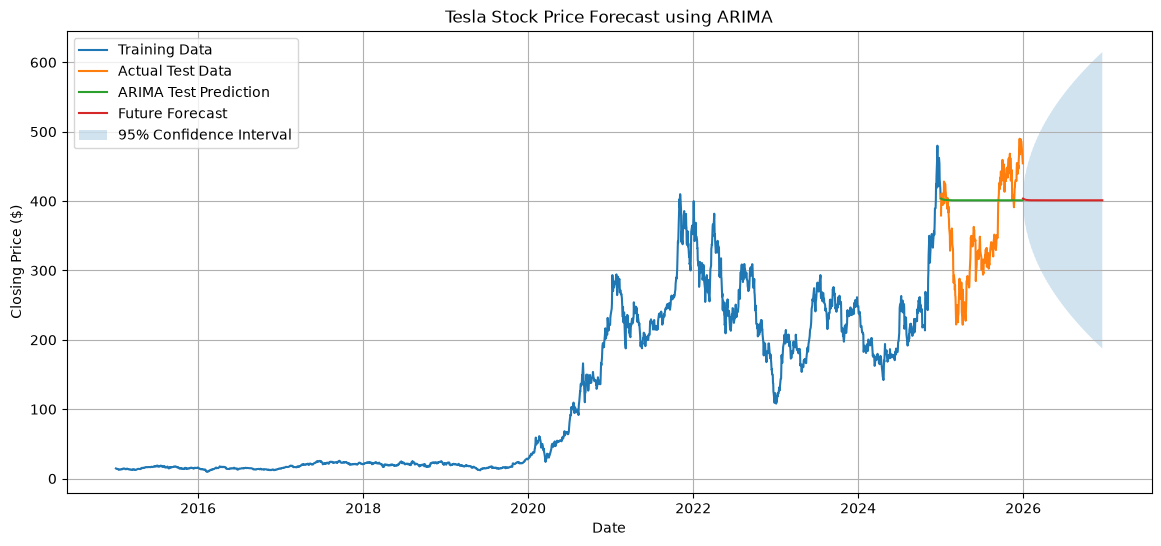

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train["Close"],
    label="Training Data"
)

plt.plot(
    test.index,
    test["Close"],
    label="Actual Test Data"
)

plt.plot(
    test.index,
    test_forecast,
    label="ARIMA Test Prediction"
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label="Future Forecast"
)

plt.fill_between(
    future_forecast.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Tesla Stock Price Forecast using ARIMA")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [26]:
def build_lstm(units1=64, units2=32, learning_rate=0.001):

    model = Sequential()

    # First LSTM layer
    model.add(
        LSTM(
            units=units1,
            return_sequences=True,
            input_shape=(60, 1)
        )
    )

    model.add(Dropout(0.2))

    # Second LSTM layer
    model.add(
        LSTM(
            units=units2,
            return_sequences=False
        )
    )

    model.add(Dropout(0.2))

    # Output layer
    model.add(
        Dense(1)
    )

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="mean_squared_error"
    )

    return model

In [27]:
model = build_lstm(
    units1=128,
    units2=64,
    learning_rate=0.0005
)

model.summary()

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 128)             │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 116,033 (453.25 KB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
best_model = model

In [29]:
future_days = 252

In [31]:
from sklearn.preprocessing import MinMaxScaler

In [33]:
scaler = MinMaxScaler(feature_range=(0,1))

train_close = train[["Close"]]

train_scaled = scaler.fit_transform(train_close)

test_scaled = scaler.transform(
    test[["Close"]]
)

In [34]:
last_sequence = scaler.transform(
    tsla[["Close"]]
).flatten()

last_sequence = last_sequence[-60:]

In [35]:
future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    x = current_sequence.reshape(1, 60, 1)

    prediction = best_model.predict(
        x,
        verbose=0
    )

    future_predictions.append(
        prediction[0,0]
    )

    current_sequence = np.append(
        current_sequence[1:],
        prediction[0,0]
    )

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_close = train[["Close"]]

train_scaled = scaler.fit_transform(train_close)

test_scaled = scaler.transform(test[["Close"]])

In [37]:
future_predictions = []

current_sequence = last_sequence.copy()

for _ in range(future_days):

    x = current_sequence.reshape(1, 60, 1)

    prediction = best_model.predict(
        x,
        verbose=0
    )

    future_predictions.append(
        prediction[0,0]
    )

    current_sequence = np.append(
        current_sequence[1:],
        prediction[0,0]
    )

In [38]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1,1)
)

In [39]:
future_dates = pd.bdate_range(
    start=tsla.index[-1] + pd.Timedelta(days=1),
    periods=future_days
)

In [40]:
forecast_df = pd.DataFrame({

    "Forecast": future_predictions.flatten()

}, index=future_dates)

forecast_df.head()

,Forecast
2025-12-31,64.024620
2026-01-01,63.790520
2026-01-02,62.434814
2026-01-05,60.034889
2026-01-06,56.822205


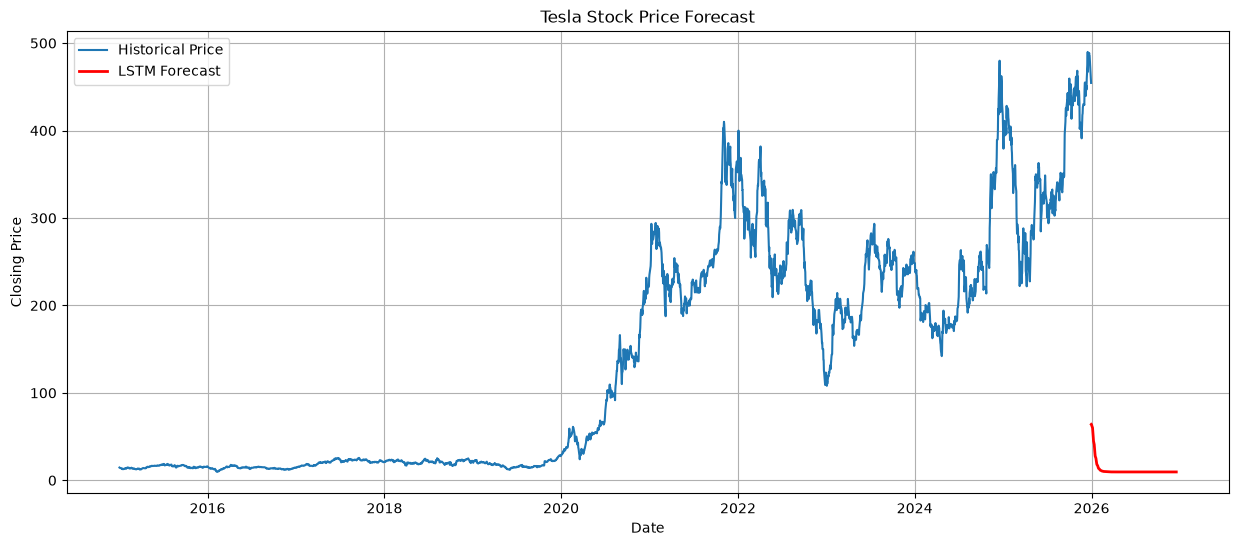

In [41]:
plt.figure(figsize=(15,6))

plt.plot(
    tsla.index,
    tsla["Close"],
    label="Historical Price"
)

plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    color="red",
    linewidth=2,
    label="LSTM Forecast"
)

plt.title("Tesla Stock Price Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [46]:
print(train.shape)
print(test.shape)

(2516, 6)
(249, 6)


In [47]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

train_scaled = scaler.fit_transform(
    train[["Close"]]
)

test_scaled = scaler.transform(
    test[["Close"]]
)

In [48]:
import numpy as np

window_size = 60

def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])

    return np.array(X), np.array(y)

In [49]:
X_train, y_train = create_sequences(
    train_scaled,
    window_size
)

X_test, y_test = create_sequences(
    test_scaled,
    window_size
)

In [51]:
predictions = model.predict(
    X_test
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [56]:
print("model:", "model" in globals())
print("X_test:", "X_test" in globals())
print("scaler:", "scaler" in globals())

model: True
X_test: True
scaler: True


In [57]:
predictions = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [58]:
predictions = scaler.inverse_transform(
    predictions
)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

In [59]:
from sklearn.metrics import mean_squared_error
import numpy as np

errors = actual.flatten() - predictions.flatten()

std = np.std(errors)

print("Forecast error standard deviation:", std)

Forecast error standard deviation: 62.51163223816442


In [60]:
residuals = actual.flatten() - predictions.flatten()

std = residuals.std()

In [61]:
forecast_df["Upper"] = (
    forecast_df["Forecast"] + 1.96 * std
)

forecast_df["Lower"] = (
    forecast_df["Forecast"] - 1.96 * std
)

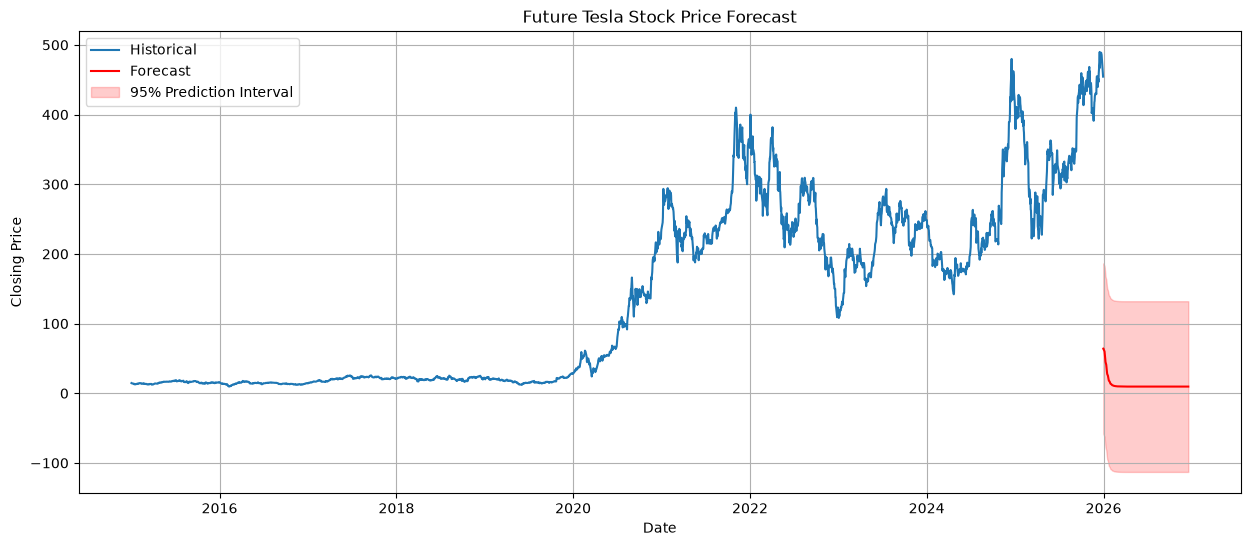

In [62]:
plt.figure(figsize=(15,6))

plt.plot(
    tsla.index,
    tsla["Close"],
    label="Historical"
)

plt.plot(
    forecast_df.index,
    forecast_df["Forecast"],
    color="red",
    label="Forecast"
)

plt.fill_between(
    forecast_df.index,
    forecast_df["Lower"],
    forecast_df["Upper"],
    color="red",
    alpha=0.2,
    label="95% Prediction Interval"
)

plt.title("Future Tesla Stock Price Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [63]:
future_forecast = arima_fit.get_forecast(
    steps=252
)

forecast = future_forecast.predicted_mean

confidence = future_forecast.conf_int()

C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Soret\portfolio-optimization\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


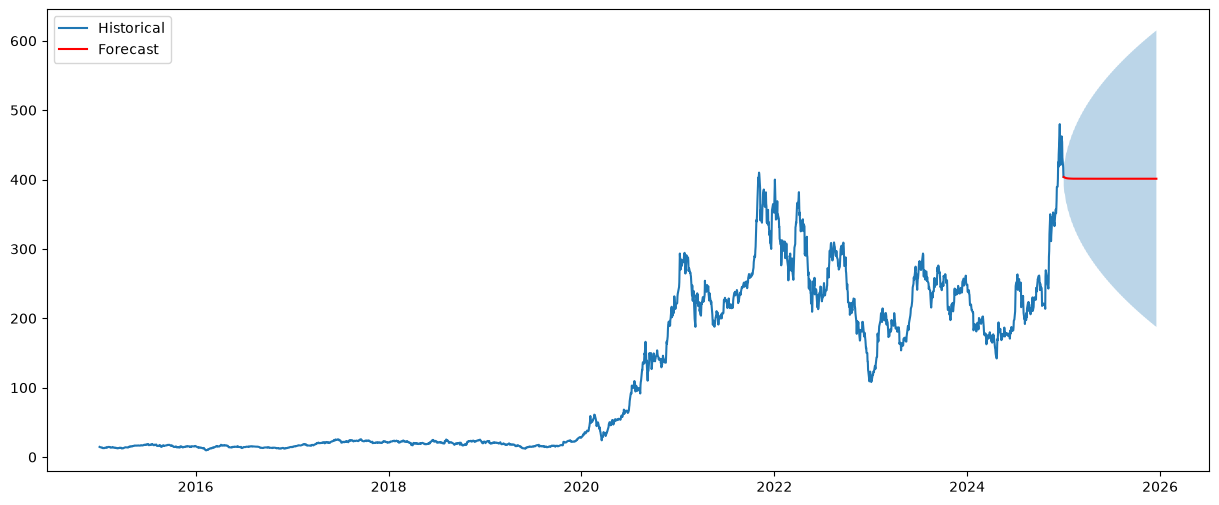

In [64]:
plt.figure(figsize=(15,6))

plt.plot(
    train_close.index,
    train_close,
    label="Historical"
)

future_dates = pd.bdate_range(
    train_close.index[-1] + pd.Timedelta(days=1),
    periods=252
)

plt.plot(
    future_dates,
    forecast,
    color="red",
    label="Forecast"
)

plt.fill_between(
    future_dates,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.3
)

plt.legend()

plt.show()

In [65]:
import numpy as np

start_price = forecast_df["Forecast"].iloc[0]
end_price = forecast_df["Forecast"].iloc[-1]

percentage_change = (
    (end_price - start_price) / start_price
) * 100

print("Starting Forecast Price:", start_price)
print("Ending Forecast Price:", end_price)
print("Forecast Change (%):", percentage_change)

Starting Forecast Price: 64.02462
Ending Forecast Price: 9.578
Forecast Change (%): -85.04013


In [66]:
forecast_df["Daily_Change"] = (
    forecast_df["Forecast"].pct_change() * 100
)

print(forecast_df["Daily_Change"].describe())

count    251.000000
mean      -0.731350
std        2.079428
min       -9.420270
25%       -0.023299
50%       -0.000012
75%        0.000000
max        0.000000
Name: Daily_Change, dtype: float64


In [67]:
threshold = forecast_df["Daily_Change"].std() * 2

anomalies = forecast_df[
    abs(forecast_df["Daily_Change"]) > threshold
]

print(anomalies)

             Forecast       Upper       Lower  Daily_Change
2026-01-06  56.822205  179.345001  -65.700592     -5.351365
2026-01-07  53.073002  175.595795  -69.449799     -6.598127
2026-01-08  49.045563  171.568359  -73.477234     -7.588488
2026-01-09  44.954121  167.476913  -77.568680     -8.342123
2026-01-12  40.961365  163.484161  -81.561432     -8.881849
2026-01-13  37.181126  159.703918  -85.341675     -9.228790
2026-01-14  33.685211  156.208008  -88.837585     -9.402389
2026-01-15  30.511972  153.034775  -92.010826     -9.420270
2026-01-16  27.674501  150.197296  -94.848297     -9.299535
2026-01-19  25.167864  147.690659  -97.354935     -9.057570
2026-01-20  22.975101  145.497894  -99.547699     -8.712548
2026-01-21  21.072128  143.594925 -101.450668     -8.282763
2026-01-22  19.430941  141.953735 -103.091858     -7.788425
2026-01-23  18.022518  140.545319 -104.500275     -7.248348
2026-01-26  16.818359  139.341156 -105.704437     -6.681413
2026-01-27  15.791649  138.314453 -106.7

In [68]:
forecast_df["CI_Width"] = (
    forecast_df["Upper"] -
    forecast_df["Lower"]
)

print(forecast_df["CI_Width"].head())
print(forecast_df["CI_Width"].tail())

2025-12-31    245.045593
2026-01-01    245.045593
2026-01-02    245.045593
2026-01-05    245.045593
2026-01-06    245.045593
Freq: B, Name: CI_Width, dtype: float32
2026-12-11    245.045593
2026-12-14    245.045593
2026-12-15    245.045593
2026-12-16    245.045593
2026-12-17    245.045593
Freq: B, Name: CI_Width, dtype: float32


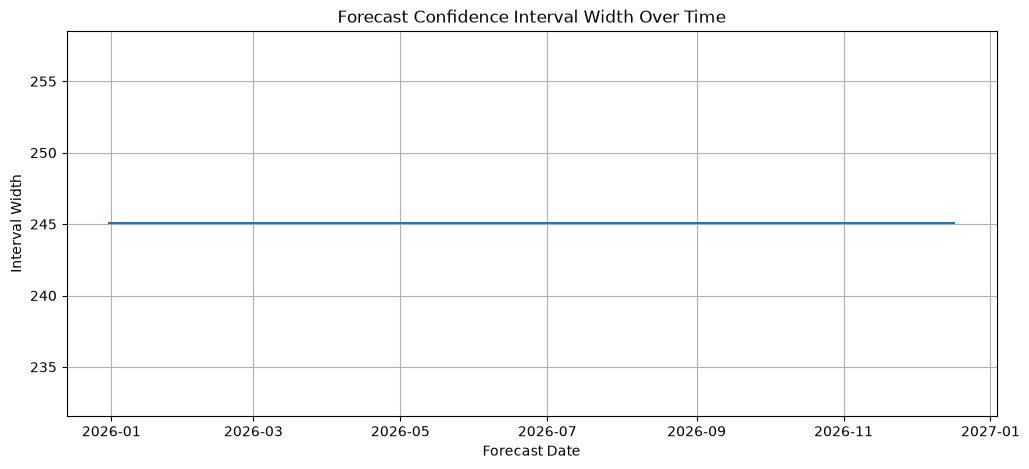

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    forecast_df.index,
    forecast_df["CI_Width"]
)

plt.title(
    "Forecast Confidence Interval Width Over Time"
)

plt.xlabel("Forecast Date")
plt.ylabel("Interval Width")

plt.grid(True)
plt.show()

In [70]:
forecast_change = (
    (forecast_df["Forecast"].iloc[-1] -
     forecast_df["Forecast"].iloc[0])
    /
    forecast_df["Forecast"].iloc[0]
) * 100

print(f"Expected forecast growth: {forecast_change:.2f}%")

Expected forecast growth: -85.04%


In [71]:
daily_returns = tsla["Close"].pct_change()

annual_volatility = (
    daily_returns.std() * np.sqrt(252)
)

print(
    "Annualized volatility:",
    annual_volatility
)

Annualized volatility: 0.5776037895469723


In [72]:
forecast_df["Uncertainty"] = (
    forecast_df["Upper"]
    -
    forecast_df["Lower"]
)

print(
    forecast_df["Uncertainty"].head()
)

print(
    forecast_df["Uncertainty"].tail()
)

2025-12-31    245.045593
2026-01-01    245.045593
2026-01-02    245.045593
2026-01-05    245.045593
2026-01-06    245.045593
Freq: B, Name: Uncertainty, dtype: float32
2026-12-11    245.045593
2026-12-14    245.045593
2026-12-15    245.045593
2026-12-16    245.045593
2026-12-17    245.045593
Freq: B, Name: Uncertainty, dtype: float32


In [73]:
import numpy as np
import pandas as pd

# Forecasted TSLA prices from best model
forecast_start = forecast_df["Forecast"].iloc[0]
forecast_end = forecast_df["Forecast"].iloc[-1]

forecast_days = len(forecast_df)

# Expected daily return from forecast
tsla_daily_expected_return = (
    (forecast_end / forecast_start) ** (1 / forecast_days)
) - 1

# Annualized expected return (252 trading days)
tsla_expected_return = (
    (1 + tsla_daily_expected_return) ** 252
) - 1

print("TSLA Expected Annual Return:")
print(tsla_expected_return)

TSLA Expected Annual Return:
-0.85040146


In [74]:
import yfinance as yf

assets = ["BND", "SPY"]

data = yf.download(
    assets,
    start="2015-01-01",
    end="2026-06-30",
    auto_adjust=False
)

prices = data["Close"]

prices.head()

[*********************100%***********************]  2 of 2 completed


Ticker,BND,SPY
Date,,
2015-01-02,82.650002,205.429993
2015-01-05,82.889999,201.720001
2015-01-06,83.129997,199.820007
2015-01-07,83.180000,202.309998
2015-01-08,83.050003,205.899994


In [75]:
returns = prices.pct_change().dropna()

returns.head()

Ticker,BND,SPY
Date,,
2015-01-05,0.002904,-0.018060
2015-01-06,0.002895,-0.009419
2015-01-07,0.000602,0.012461
2015-01-08,-0.001563,0.017745
2015-01-09,0.001686,-0.008014


In [76]:
bnd_expected_return = (
    returns["BND"].mean() * 252
)

spy_expected_return = (
    returns["SPY"].mean() * 252
)

print("BND Expected Return:", bnd_expected_return)
print("SPY Expected Return:", spy_expected_return)

BND Expected Return: -0.0085477094765082
SPY Expected Return: 0.12774562865671302


In [77]:
expected_returns = pd.Series(
    {
        "TSLA": tsla_expected_return,
        "BND": bnd_expected_return,
        "SPY": spy_expected_return
    }
)

print(expected_returns)

TSLA   -0.850401
BND    -0.008548
SPY     0.127746
dtype: float64


In [78]:
import yfinance as yf
import pandas as pd

assets = ["TSLA", "BND", "SPY"]

data = yf.download(
    assets,
    start="2015-01-01",
    end="2026-06-30",
    auto_adjust=False,
    progress=False
)

# Extract closing prices
prices = data["Close"]

print(prices.head())

Ticker            BND         SPY       TSLA
Date                                        
2015-01-02  82.650002  205.429993  14.620667
2015-01-05  82.889999  201.720001  14.006000
2015-01-06  83.129997  199.820007  14.085333
2015-01-07  83.180000  202.309998  14.063333
2015-01-08  83.050003  205.899994  14.041333


In [79]:
daily_returns = prices.pct_change().dropna()

print(daily_returns.head())

Ticker           BND       SPY      TSLA
Date                                    
2015-01-05  0.002904 -0.018060 -0.042041
2015-01-06  0.002895 -0.009419  0.005664
2015-01-07  0.000602  0.012461 -0.001562
2015-01-08 -0.001563  0.017745 -0.001564
2015-01-09  0.001686 -0.008014 -0.018802


In [80]:
cov_matrix_daily = daily_returns.cov()

print("Daily Covariance Matrix:")
print(cov_matrix_daily)

Daily Covariance Matrix:
Ticker       BND       SPY      TSLA
Ticker                              
BND     0.000011  0.000004  0.000007
SPY     0.000004  0.000125  0.000198
TSLA    0.000007  0.000198  0.001297


In [81]:
trading_days = 252

cov_matrix_annual = cov_matrix_daily * trading_days

print("Annualized Covariance Matrix:")
print(cov_matrix_annual)

Annualized Covariance Matrix:
Ticker       BND       SPY      TSLA
Ticker                              
BND     0.002883  0.001045  0.001793
SPY     0.001045  0.031402  0.049795
TSLA    0.001793  0.049795  0.326926


In [83]:
import numpy as np
import pandas as pd

from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import plotting

In [84]:
assets = ["TSLA", "BND", "SPY"]

expected_returns = expected_returns[assets]

cov_matrix_annual = cov_matrix_annual.loc[
    assets,
    assets
]

print(expected_returns)
print(cov_matrix_annual)

TSLA   -0.850401
BND    -0.008548
SPY     0.127746
dtype: float64
Ticker      TSLA       BND       SPY
Ticker                              
TSLA    0.326926  0.001793  0.049795
BND     0.001793  0.002883  0.001045
SPY     0.049795  0.001045  0.031402


In [85]:
ef = EfficientFrontier(
    expected_returns,
    cov_matrix_annual
)

weights = ef.max_sharpe()

cleaned_weights = ef.clean_weights()

print("Optimal Portfolio Weights:")
print(cleaned_weights)

Optimal Portfolio Weights:
OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])


In [86]:
expected_return, volatility, sharpe_ratio = ef.portfolio_performance(
    verbose=True
)

Expected annual return: 12.8%
Annual volatility: 17.7%
Sharpe Ratio: 0.72


In [87]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt


mu = expected_returns.values
Sigma = cov_matrix_annual.values

n_assets = len(mu)

# Portfolio return
def portfolio_return(weights):
    return np.dot(weights, mu)


# Portfolio risk
def portfolio_volatility(weights):
    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(Sigma, weights)
        )
    )


target_returns = np.linspace(
    mu.min(),
    mu.max(),
    50
)

frontier_volatility = []


for target in target_returns:

    constraints = [
        {
            "type": "eq",
            "fun": lambda w: np.sum(w)-1
        },
        {
            "type": "eq",
            "fun": lambda w:
                portfolio_return(w)-target
        }
    ]

    bounds = [(0,1)] * n_assets

    result = minimize(
        portfolio_volatility,
        np.ones(n_assets)/n_assets,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    frontier_volatility.append(
        result.fun
    )

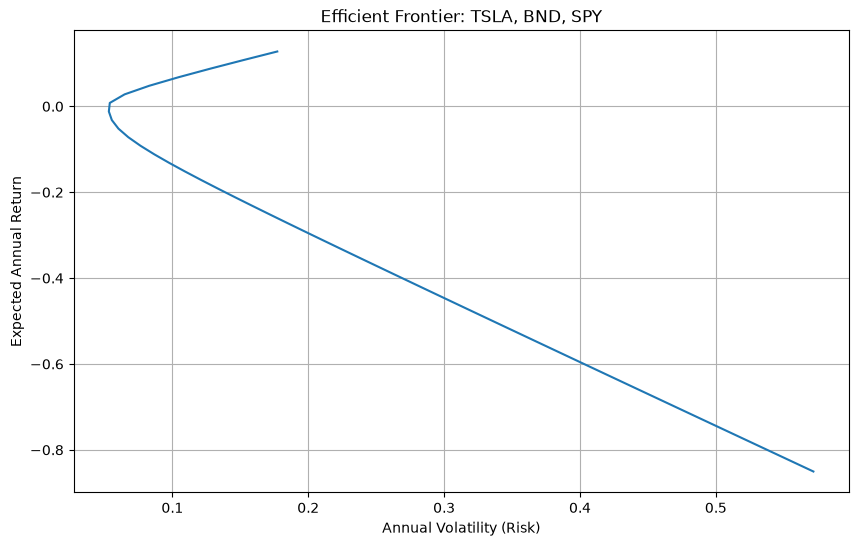

In [88]:
plt.figure(figsize=(10,6))

plt.plot(
    frontier_volatility,
    target_returns
)

plt.xlabel(
    "Annual Volatility (Risk)"
)

plt.ylabel(
    "Expected Annual Return"
)

plt.title(
    "Efficient Frontier: TSLA, BND, SPY"
)

plt.grid(True)
plt.show()

In [89]:
from pypfopt import EfficientFrontier

# Maximum Sharpe portfolio
ef_sharpe = EfficientFrontier(
    expected_returns,
    cov_matrix_annual
)

sharpe_weights = ef_sharpe.max_sharpe()

sharpe_return, sharpe_volatility, sharpe_ratio = (
    ef_sharpe.portfolio_performance()
)

print("Maximum Sharpe Portfolio")
print(sharpe_weights)
print("Return:", sharpe_return)
print("Risk:", sharpe_volatility)
print("Sharpe Ratio:", sharpe_ratio)

Maximum Sharpe Portfolio
OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])
Return: 0.12774562865671302
Risk: 0.1772049256011732
Sharpe Ratio: 0.7208920870756386


In [90]:
ef_min = EfficientFrontier(
    expected_returns,
    cov_matrix_annual
)

min_vol_weights = ef_min.min_volatility()

min_return, min_volatility, min_sharpe = (
    ef_min.portfolio_performance()
)

print("\nMinimum Volatility Portfolio")
print(min_vol_weights)
print("Return:", min_return)
print("Risk:", min_volatility)


Minimum Volatility Portfolio
OrderedDict([('TSLA', 0.0), ('BND', 0.9429116596833524), ('SPY', 0.0570883403166476)])
Return: -0.000766949006266943
Risk: 0.052710525470578216


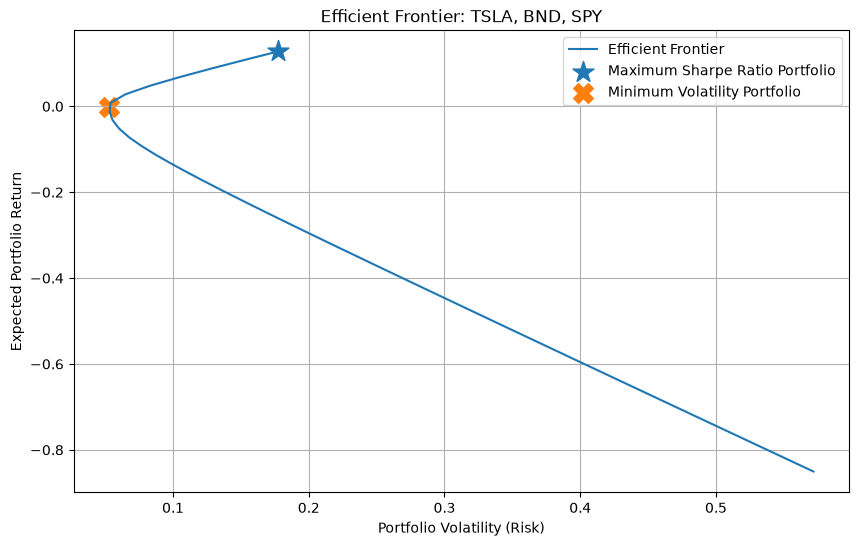

In [91]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

# Efficient frontier curve
plt.plot(
    frontier_volatility,
    target_returns,
    label="Efficient Frontier"
)


# Maximum Sharpe Portfolio
plt.scatter(
    sharpe_volatility,
    sharpe_return,
    marker="*",
    s=250,
    label="Maximum Sharpe Ratio Portfolio"
)


# Minimum Volatility Portfolio
plt.scatter(
    min_volatility,
    min_return,
    marker="X",
    s=200,
    label="Minimum Volatility Portfolio"
)


plt.xlabel(
    "Portfolio Volatility (Risk)"
)

plt.ylabel(
    "Expected Portfolio Return"
)

plt.title(
    "Efficient Frontier: TSLA, BND, SPY"
)

plt.legend()
plt.grid(True)

plt.show()

In [92]:
print("Maximum Sharpe Weights:")
print(
    ef_sharpe.clean_weights()
)

Maximum Sharpe Weights:
OrderedDict([('TSLA', 0.0), ('BND', 0.0), ('SPY', 1.0)])


In [93]:
print("Minimum Volatility Weights:")
print(
    ef_min.clean_weights()
)

Minimum Volatility Weights:
OrderedDict([('TSLA', 0.0), ('BND', 0.94291), ('SPY', 0.05709)])
